# *Trajectory Inference*

We performed pseudotemporal analysis on cells belonging to clusters 0, 2, 3 and 4, to generate pseudotime trajectories toward the exploration of cell progression dynamics. Cells classified within cluster 1 and identified as monocytes were excluded from the analysis as they represent a distinct cellular lineage not directly associated with BC cellular transitions.

## Load Libraries and annotated AnnData object

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colorbar
from matplotlib import rcParams
import scanpy as sc

In [42]:
# Load your annotated AnnData object
adata2 = sc.read_h5ad("/YourProjectFolder/your_data_file.h5ad")

Filter cell tyes of interest.

In [43]:
# List of cell types to keep
cell_types_to_keep = ['Mesenchymal stem cell', 'Epithelial cell', 'Stem cell']

# Filter the AnnData object based on the 'cell_type' column in .obs
adata = adata2[adata2.obs['cell_type'].isin(cell_types_to_keep)].copy()


In [44]:
# # List of cell types to keep
# cell_types_to_keep = ['0', '4', '3', '2']

# # Filter the AnnData object based on the 'cell_type' column in .obs
# adata = adata2[adata2.obs['leiden_res_0.3'].isin(cell_types_to_keep)].copy()

## Diffusion maps

We’ll now perform an optional step, that basically takes the place of the PCA. Instead of using PCs, we can use diffusion maps.

In [47]:
sc.tl.diffmap(adata)

Now that we have our diffusion map, we need to re-calculate neighbors using the diffusion map instead of the PCs. Then we re-draw and plot a new force directed graph using the new neighbors.

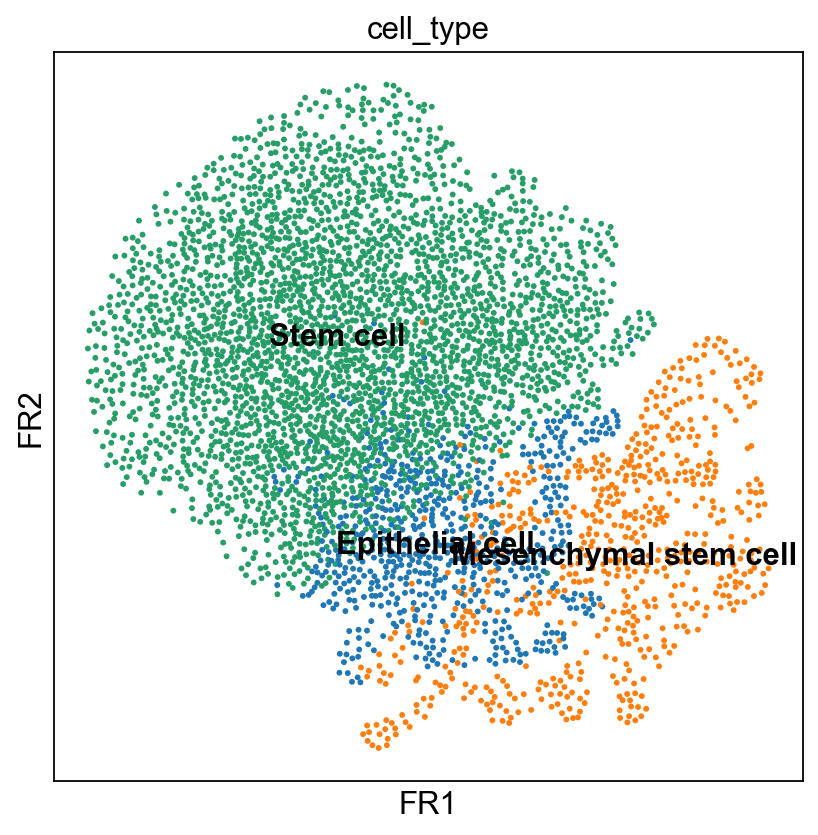

In [48]:
sc.pp.neighbors(adata, n_neighbors=15, use_rep='X_diffmap')
sc.tl.draw_graph(adata)
sc.pl.draw_graph(adata, color='cell_type', legend_loc='on data')

## PAGA

PAGA is used to generalise relationships between groups, or likely clusters, in this case.

In [49]:
#sc.tl.paga(adata, groups='leiden_res_0.3')
sc.tl.paga(adata, groups='cell_type')

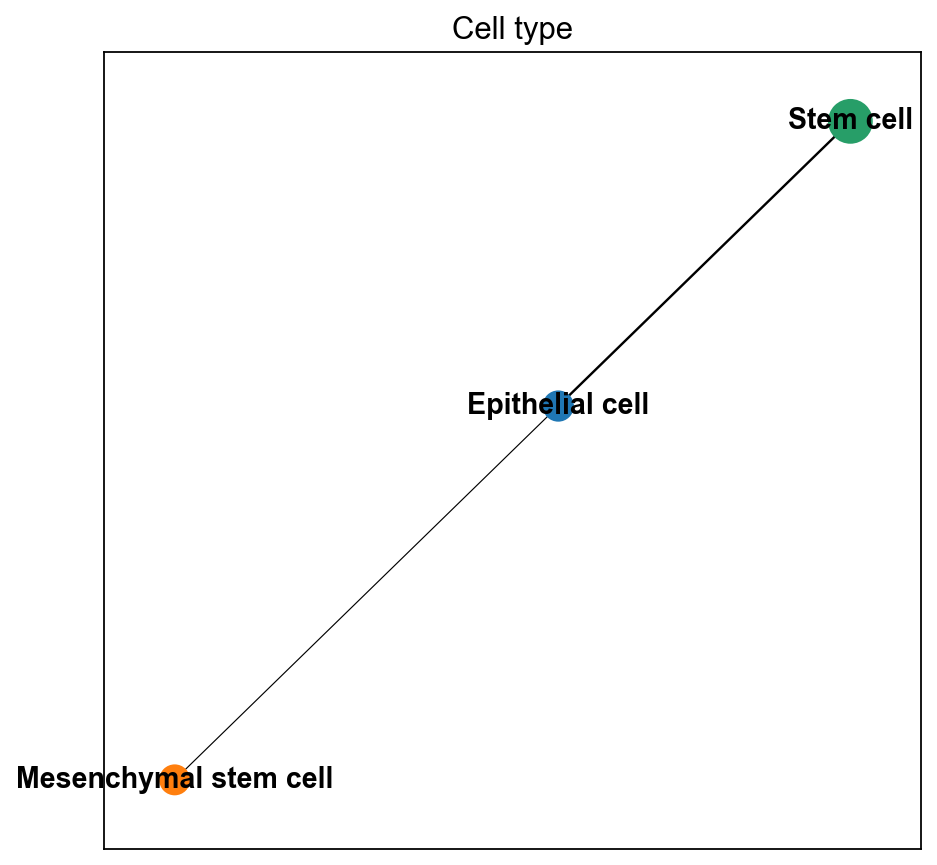

In [50]:
sc.pl.paga(adata, color=['cell_type'], title=['Cell type'])

## Re-draw force-directed graph

Force directed graphs can be initialised randomly, or we can prod it in the right direction. We’ll prod it with our PAGA calculations. Note that you could also try prodding it with tSNE or UMAP. A lot of these tools can be used on top of each other or with each other in different ways, this tutorial is just one example. Similarly, you could be using any obs information for grouping, so could do this for louvain or cell_type for instance.

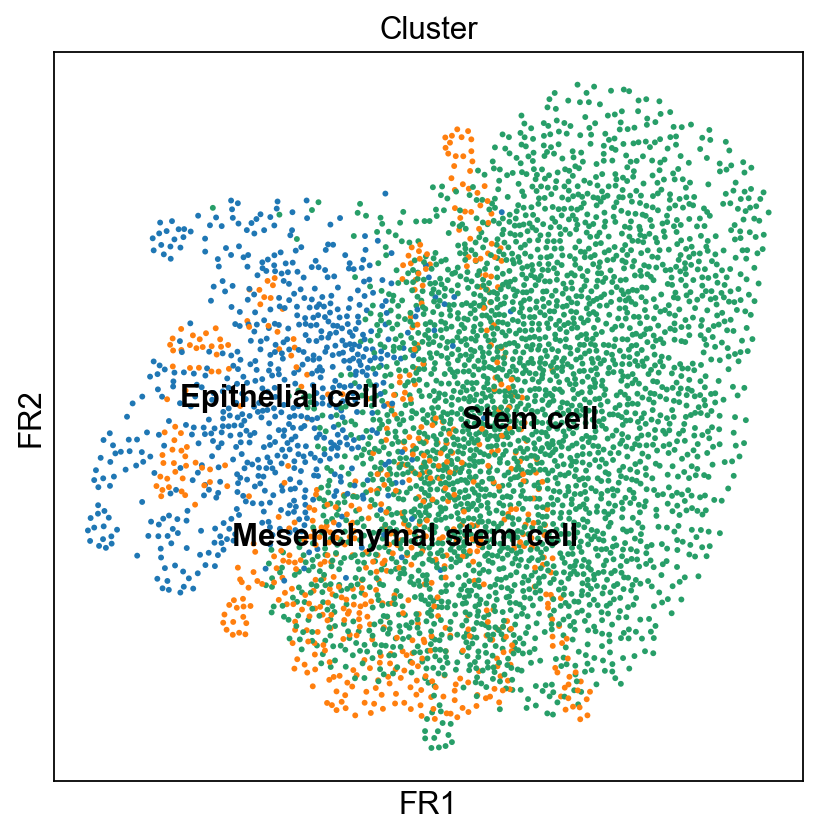

In [52]:
sc.tl.draw_graph(adata, init_pos='paga')

sc.pl.draw_graph(adata, color=['cell_type'], title=['Cluster'], legend_loc='on data')

In [53]:
adata.var

,gene_ids,feature_types,n_cells,mt,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
HES4,ENSG00000188290,Gene Expression,1241,False,1241,0.448864,0.370780,80.413510,2844.0,7.953318,True,0.357399,1.585941,0.723357,0.189273,0.457055
ISG15,ENSG00000187608,Gene Expression,432,False,432,0.079072,0.076101,93.181818,501.0,6.218600,True,0.088269,1.583300,0.894663,0.048180,0.211133
MXRA8,ENSG00000162576,Gene Expression,185,False,185,0.034091,0.033523,97.080177,216.0,5.379897,True,0.044326,1.821537,1.527785,0.021549,0.151720
MMP23B,ENSG00000189409,Gene Expression,115,False,115,0.021622,0.021392,98.184975,137.0,4.927254,True,0.030086,1.822554,1.530486,0.014135,0.125494
PEX10,ENSG00000157911,Gene Expression,284,False,284,0.045928,0.044905,95.517677,291.0,5.676754,True,0.052289,1.441726,0.518429,0.029178,0.161348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ATP8,ENSG00000228253,Gene Expression,962,True,962,0.185448,0.170121,84.816919,1175.0,7.069874,True,0.253445,1.823433,1.532822,0.127207,0.375622
MT-ND3,ENSG00000198840,Gene Expression,5952,True,5952,9.503945,2.351751,6.060606,60217.0,11.005727,True,2.667138,2.712608,1.567941,2.277549,0.914700
MT-ND4L,ENSG00000212907,Gene Expression,3963,True,3963,1.534722,0.930084,37.452652,9724.0,9.182455,True,1.260240,2.129987,1.766782,0.816117,0.844396
MT-ND5,ENSG00000198786,Gene Expression,5251,True,5251,4.656250,1.732761,17.124369,29502.0,10.292247,True,2.075021,2.672179,5.046798,1.557133,0.997731


## Diffusion pseudotime

First, let’s name our ‘root’.

To define the root of the trajectory, we selected the previously identified stem cell population, as these cells represent the earliest stage of the differentiation process.

In [56]:
adata.uns['iroot'] = np.flatnonzero(adata.obs['cell_type']  == 'Stem cell')[0]
#adata.uns['iroot'] = np.flatnonzero(adata.obs['leiden_res_0.3']  == '0')[0]

In [57]:
sc.tl.dpt(adata)


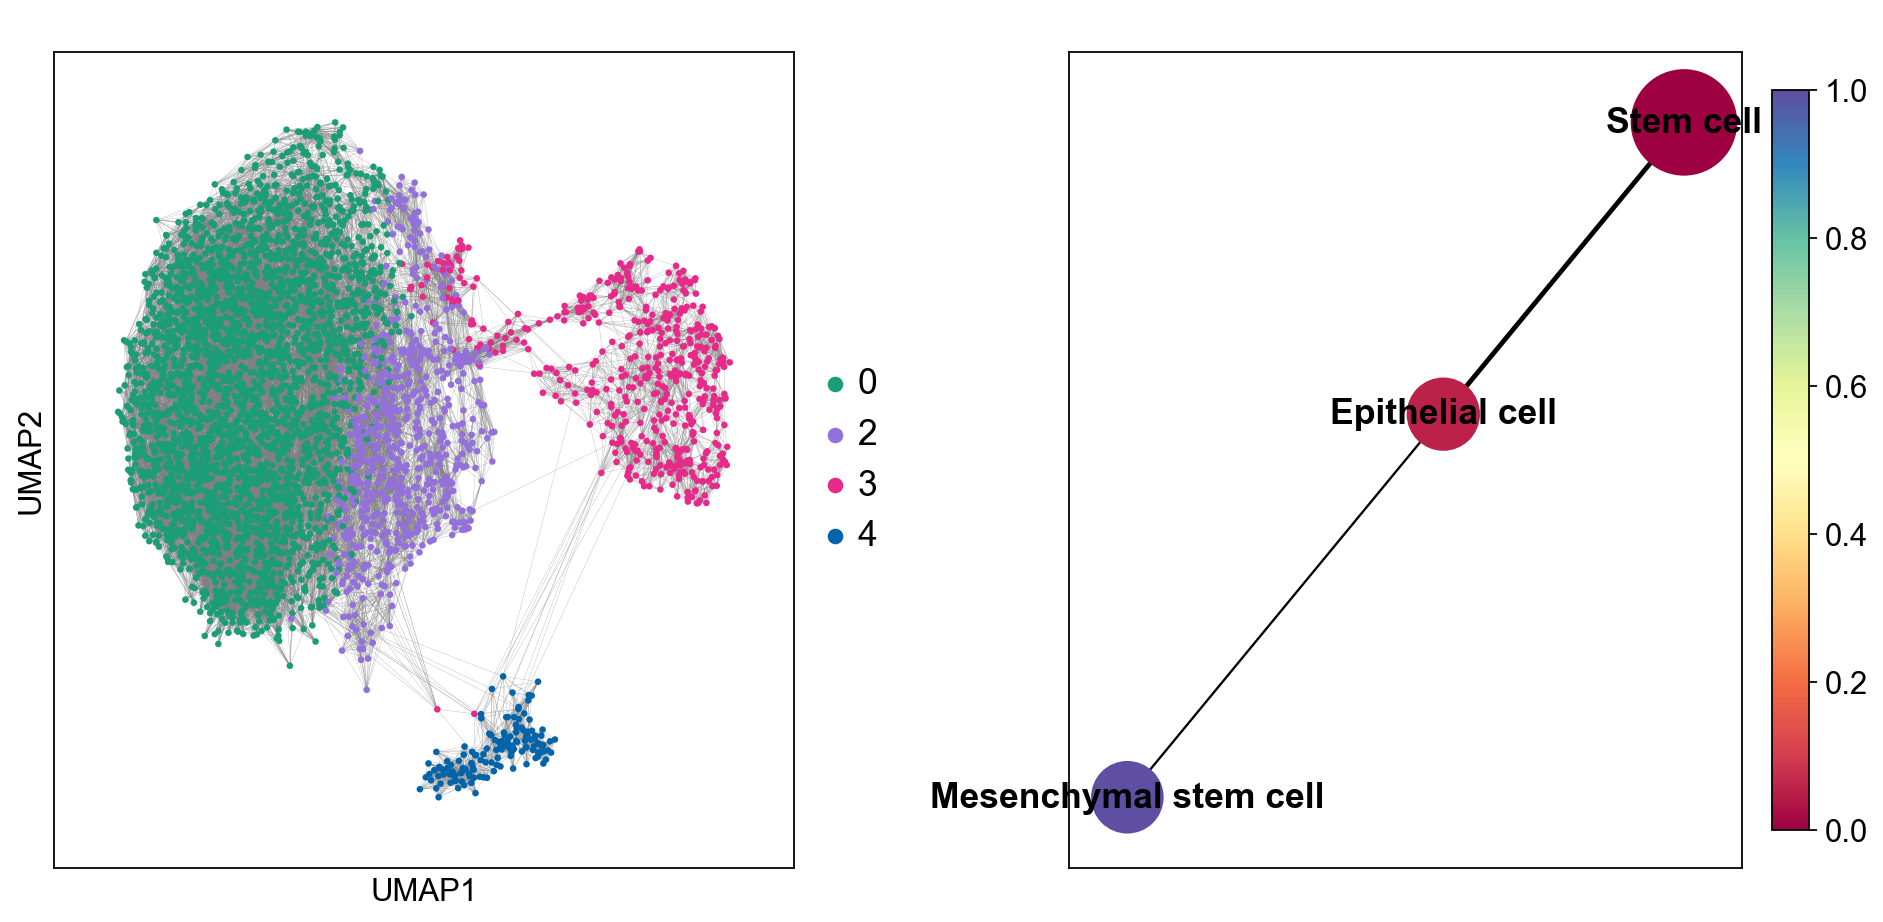

In [65]:
# Create a side-by-side layout
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Create a custom palette
custom_palette_cells = ['#1b9e77', '#9370db', '#e7298a', '#0064aa']

# UMAP plot (for reference)
sc.pl.umap(adata, 
           color=["leiden_res_0.3"],  
           edges=True,
           size=35,
           legend_fontsize=16,
           legend_fontoutline=10,
           #frameon=False,
           title=" ",
           palette=custom_palette_cells,
           ax=axes[0],  # Use the first subplot
           show=False  # Prevent immediate display
           )

# PAGA plot (without the colorbar)
sc.pl.paga(adata, 
           color=['dpt_pseudotime'], 
           #title="PAGA Plot",    
           layout='fr',  # Layout style for the graph
           cmap=plt.cm.Spectral,
           #fontoutline=2,
           node_size_scale=6, 
           edge_width_scale=2,
           left_margin=10,
           fontsize=16,
           arrowsize=12,
           ax=axes[1],  # Use the second subplot
           colorbar=False,  # Disable automatic colorbar
           show=False  # Prevent immediate display
           )

# Manually add a colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.Spectral, norm=plt.Normalize(vmin=adata.obs['dpt_pseudotime'].min(), vmax=adata.obs['dpt_pseudotime'].max()))
sm._A = []  # Empty array to avoid warnings

# Add the colorbar to the figure with a custom position
cbar = fig.colorbar(sm, ax=axes[1], fraction=0.05, pad=0.04)
#cbar.set_label('DPT Pseudotime', fontsize=16)

# Adjust layout and save
plt.tight_layout()
plt.savefig('combined_umap_paga_with_custom_colorbar.pdf', dpi=300)  # Save as PNG
plt.show()


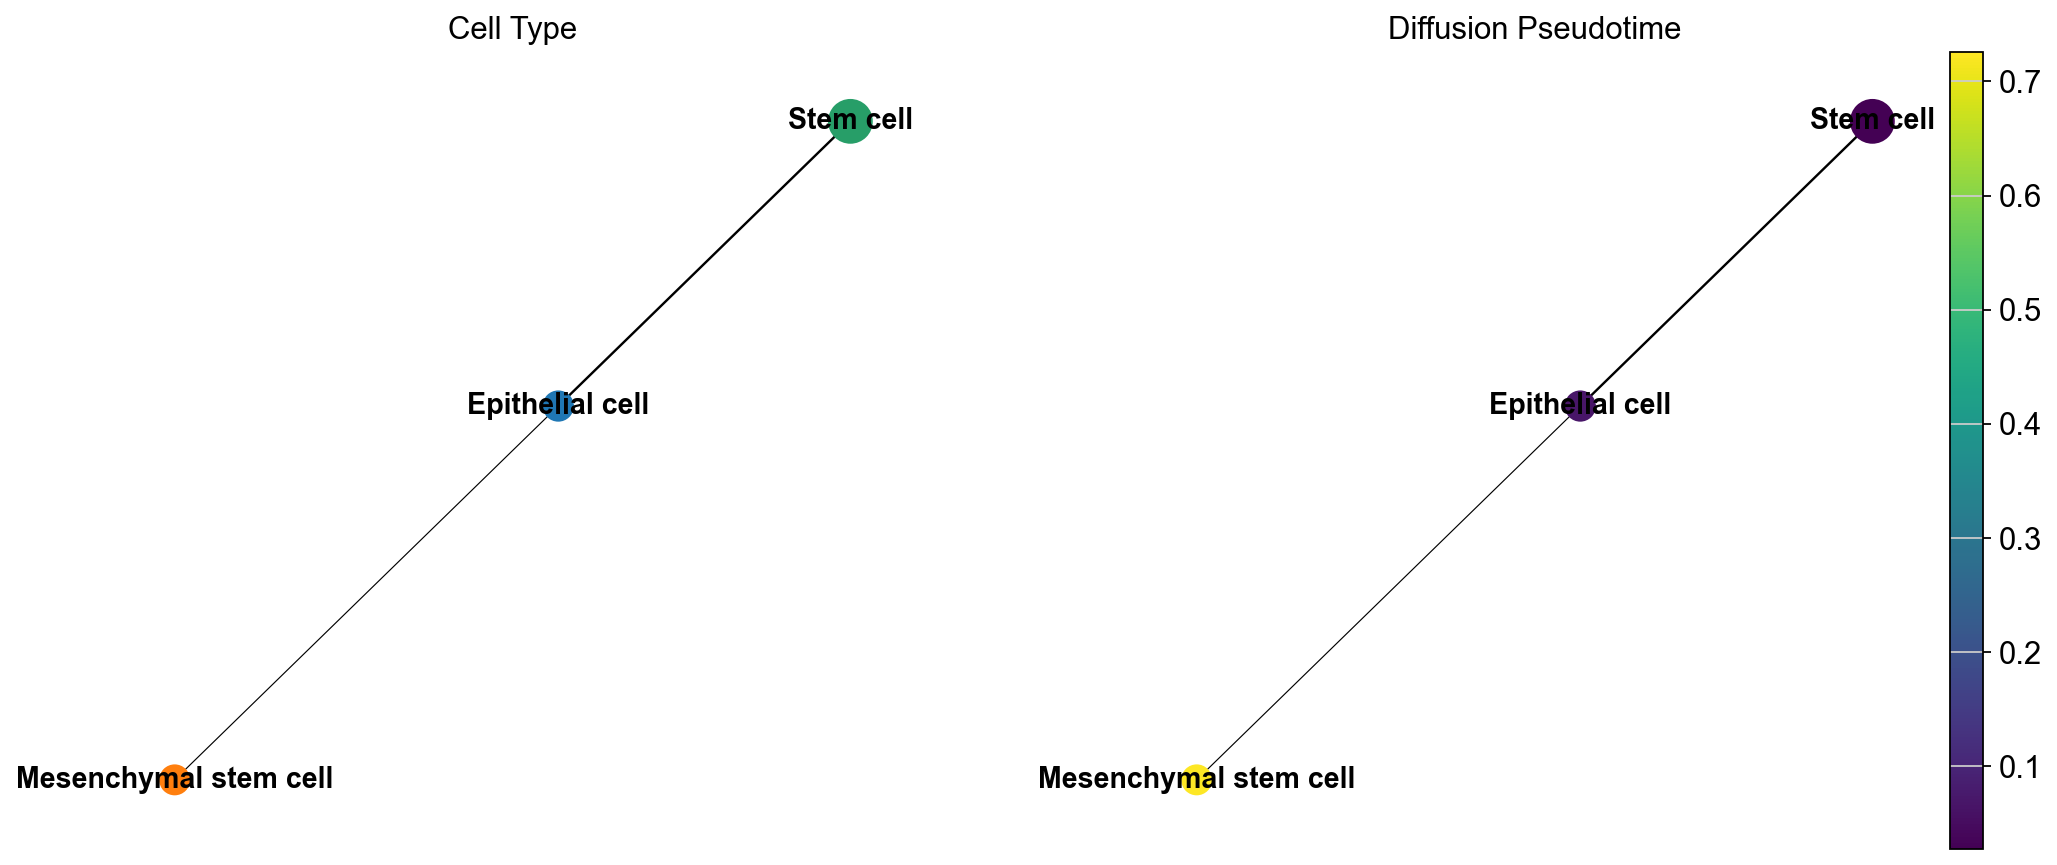

In [64]:
sc.pl.paga(adata, 
           color=['cell_type', 'dpt_pseudotime'], 
           title=['Cell Type', 'Diffusion Pseudotime'],    
           frameon=False)

## Save results

In [ ]:
adata.write('Trajectory_scRNAseqDBC.h5ad')